Datu kopa: 12330 rindas, 28 kolonnas

=== PageValues statistika: ===
count    1.233000e+04
mean     1.383052e-16
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


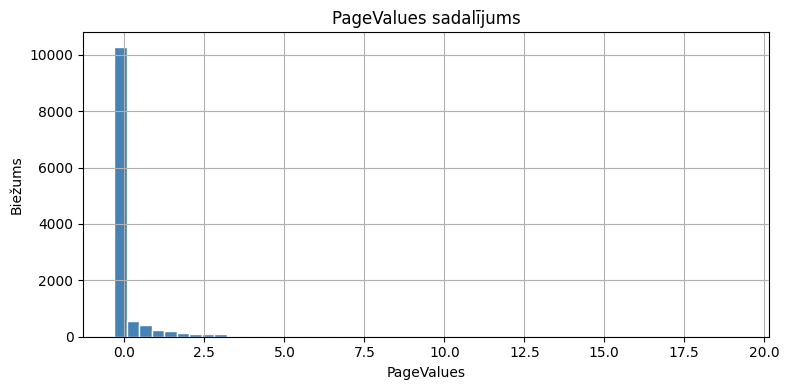

Features skaits: 26
Target: PageValues

=== Treniņu kopa: ===
Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

=== Lineāra regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


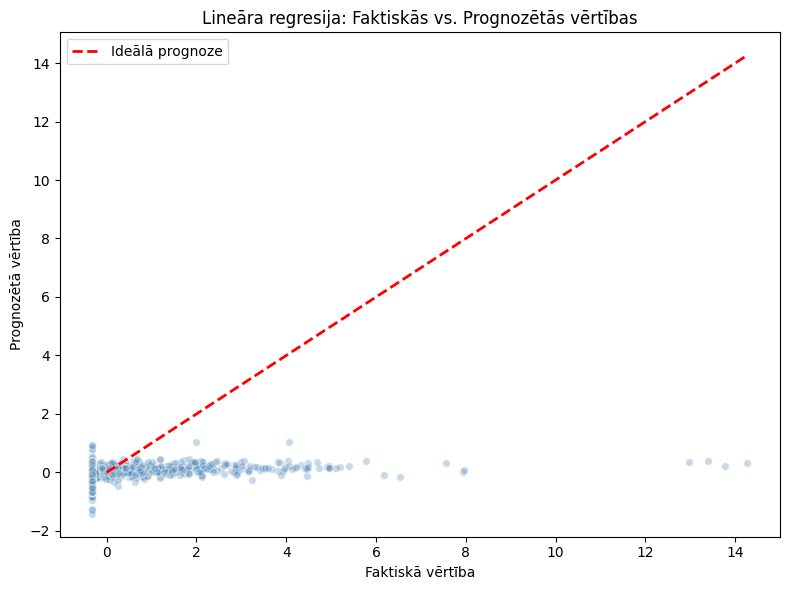

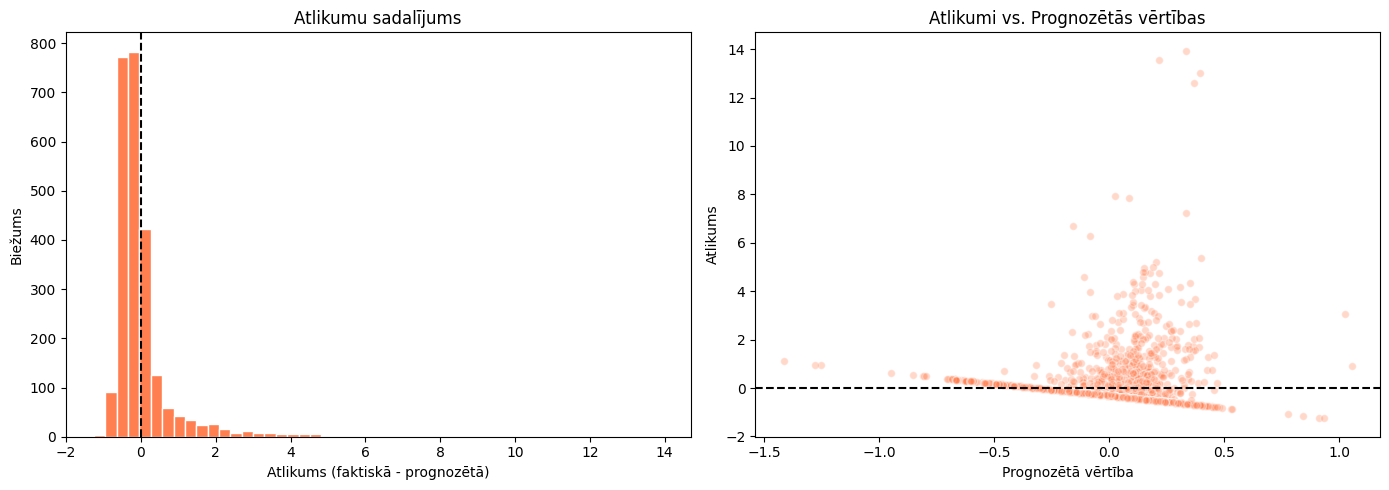


=== Polinomiālā regresija (degree=2): rezultāti ===
MSE:  0.9987
MAE:  0.4888
RMSE: 0.9993
R²:   0.0364

=== Regression Results Summary ===
                Model    MSE   RMSE    MAE     R²
    Linear Regression 0.9892 0.9946 0.5009 0.0456
Polynomial (degree=2) 0.9987 0.9993 0.4888 0.0364

=== Overfitting pārbaude (R² salīdzinājums) ===
Lineārā regresija:
Train R²: 0.0568
Test R²:  0.0456

Polinomiālā regresija:
Train R²: 0.1334
Test R²:  0.0364

--- Analīze ---
Linear Regression: Ļoti labi! Overfitting ir 0.0112 (zem 0.1)
Polynomial (degree=2): Ļoti labi! Overfitting ir 0.0971 (zem 0.1)


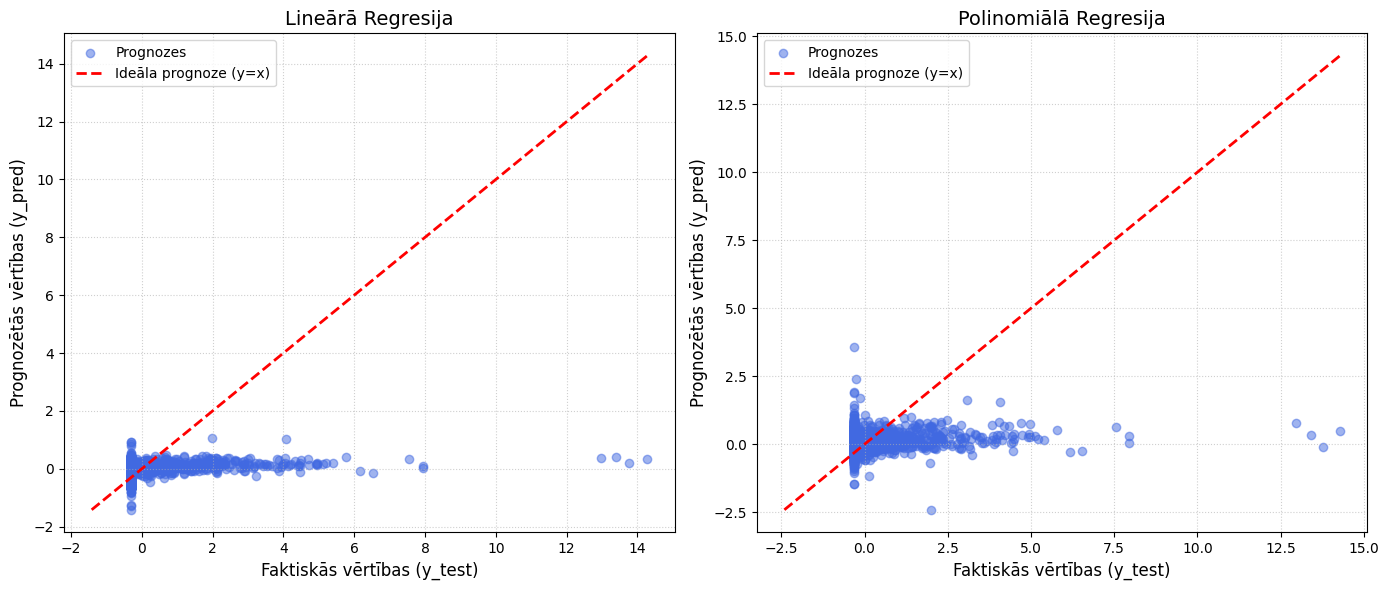

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 1. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('/content/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

# 1.2. Izvēlies target un features
# Regresijas uzdevumam mums vajag nepārtrauktu target mainīgo. Izmantosim PageValues:
# Apskatām target mainīgo

print("\n=== PageValues statistika: ===")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

# 1.3. Sagatavo X un y
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

# 1.4. Treniņa/testa sadalījums
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n=== Treniņu kopa: ===")
print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

# 2.1. Modeļa trenēšana
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# 3.1. Faktiskās vs. prognozētās vērtības
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

# 3.2. Atlikumu (residuals) analīze
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

# 4. uzdevums. Izmēģini polinomiālo regresiju
# 4.1. PolynomialFeatures ar degree=2
# Polinomiālā regresija var uztvert nelineāras sakarības. Izmēģini piemērot jaunus features - x², kas padarīs modeli elastīgāku.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveido pipeline: PolynomialFeatures → LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("\n=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MSE:  {mse_poly:.4f}")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

import pandas as pd

# Define data
results_data = [
    {
        "Model": "Linear Regression",
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    },
    {
        "Model": "Polynomial (degree=2)",
        "MSE": mse_poly,
        "RMSE": rmse_poly,
        "MAE": mae_poly,
        "R²": r2_poly
    }
]

# Create the DataFrame
df = pd.DataFrame(results_data)

# 3. Print the table with formatted numbers
# Setting index=False removes the row numbers (0, 1)
print("\n=== Regression Results Summary ===")
print(df.to_string(index=False, formatters={
    "MSE": "{:.4f}".format,
    "RMSE": "{:.4f}".format,
    "MAE": "{:.4f}".format,
    "R²": "{:.4f}".format
}))

# 5. Overfitting (pārmācīšanās) pārbaude
print("\n=== Overfitting pārbaude (R² salīdzinājums) ===")

# Prognozes uz treniņu datiem
y_train_pred_lr = lr_model.predict(X_train)
y_train_pred_poly = poly_pipeline.predict(X_train)

# R² aprēķināšana
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_pred)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_pred_poly)

print("Lineārā regresija:")
print(f"Train R²: {r2_train_lr:.4f}")
print(f"Test R²:  {r2_test_lr:.4f}")

print("\nPolinomiālā regresija:")
print(f"Train R²: {r2_train_poly:.4f}")
print(f"Test R²:  {r2_test_poly:.4f}")

# Definējam slieksni
THRESHOLD = 0.1

# Pārbaude katram modelim atsevišķi
def check_overfitting(name, train_r2, test_r2):
    diff = train_r2 - test_r2
    if diff > THRESHOLD:
        return f"{name}: Slikti! Overfitting ir {diff:.4f} (virs {THRESHOLD})"
    else:
        return f"{name}: Ļoti labi! Overfitting ir {diff:.4f} (zem {THRESHOLD})"

# Analīze
print("\n--- Analīze ---")
print(check_overfitting("Linear Regression", r2_train_lr, r2_test_lr))
print(check_overfitting("Polynomial (degree=2)", r2_train_poly, r2_test_poly))


# 4.4. Vizuāls salīdzinājums
import matplotlib.pyplot as plt
import numpy as np

# 1. Sagatavojam prognozes, izmantojot tavus mainīgo nosaukumus
y_pred_lin = lr_model.predict(X_test)         # Tavā kodā lineārais modelis ir 'model'
y_pred_poly = poly_pipeline.predict(X_test) # Tavā kodā poly modelis ir 'poly_model' un dati 'X_test_p'

# 2. Definējam datus iterācijai (grafika virsraksts, prognozētās vērtības)
models_data = [
    ("Lineārā Regresija", y_pred_lin),
    ("Polinomiālā Regresija", y_pred_poly)
]

# 3. Izveidojam subplots (1 rinda, 2 kolonnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (title, y_pred) in enumerate(models_data):
    ax = axes[i]

    # Scatter grafiks faktiskajām vs prognozētajām vērtībām
    ax.scatter(y_test, y_pred, alpha=0.5, color='royalblue', label='Prognozes')

    # Ideālā līnija (y = x)
    # Aprēķinām robežas, lai līnija precīzi saskanētu ar grafika asīm
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideāla prognoze (y=x)')

    # Noformējums
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Faktiskās vērtības (y_test)", fontsize=12)
    ax.set_ylabel("Prognozētās vērtības (y_pred)", fontsize=12)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Markdown šūna: Paskaidro, kāpēc mēs izņēmām kolonnu Revenue no features. Hint: Kas ir data leakage un kāpēc tas ir bīstami?
Jo Revenue uzreiz pasaka priekšā MI sakarību starp PageValues un iznākumu, bet mēs gribam lai MI pats izdomātu sakarības !!!

2.2. Interpretē metrikas (Markdown šūna)
Uzraksti Markdown šūnu, kurā saviem vārdiem paskaidro:
- Ko nozīmē MAE (Mean Absolute Error)? Cik “tuvu” modelis prognozē vidēji? Vidējā absolūtā kļūda rāda par cik mēs novirzāmies prognozējot no fakta, bet VIDĒJI gan + , gan - virzienā. Mūsu gadījumā MSE:  0.5009 augšgalā jo mūsu skala ir 0 - 65, tāpēc var secināt, ka modelis pietiekoši labi raksturo datubāzi  . Ja nav svarīgi vai uz augšu vai uz leju, tad MAE var lietot.
- Ko nozīmē RMSE (Root Mean Squared Error)? Kāpēc lielākas kļūdas tiek sodītas vairāk? RMSE lielākās kļūdas izceļ (kvadrātā !!!) un tās pa vienai būtiskāk iespaido rezultātu nekā vairākas mazās kļūdas kopā. Modelis izķer lielās novirzes, ko MAE nerāda. Ja tas ir svarīgi, tad jālieto RMSE, piem. pašbraucoša auto gadījumā, maza kļūda (daži cm) neko nopietnu nedod, bet liela kļūda (daži m) sadauza mašīnu, kas nav pieļaujams. Mūsu gadījumā RMSE = 0.9946, kas saka, ka lielu noviržu vispār nav.
- Ko nozīmē R² (R-squared)? Ko nozīmē vērtība, ko tu ieguvi?
R2 rāda cik katrs datubāzes lielus novirzās no vidējā, jeb cik lielu datu apjomu šis modelis paskaidro no jūsu datu bāzes. Negatīvs rezultāts ir ļoti slikti, ja tuvojas 0 , tad tā ir vidējā temperatūra slimnīcā. Ja tuvojas 1, tad ir OK. MūsuR2 ir 0.04, kas nav nekas labs, resp. šis modelis gandrīz neko nepaskaidro. Nav labs.
- MSE ir vidējā kvadrātiskā novirze ko lieto dators (tam vieglāk tā saprast), bet RMSE lieto cilvēks, ko savukārt vinām ir vieglāk saprast.
- Vai modelis ir labs vai slikts? Kāpēc tu tā domā?

3.3. Interpretē vizualizācijas (Markdown šūna)
Uzraksti Markdown šūnu, kurā atbildi:
- Vai punkti scatter grafikā ir tuvu sarkanai līnijai? Ko tas nozīmē par modeļa precizitāti?
Manuprāt punkti nav tuvu sarkanajai līnijai, kas parāda, ka modeļa precizitāte nav laba
- Vai atlikumi ir vienmērīgi sadalīti ap 0? Vai ir kāds bias?
Atlikumi nav vienmērīgi sadalīti ap 0 un man liekas, ka lineārā regresija slikti raksturo datus, parasta taisne manuprāt nestrādā.

4.5. Secinājumi (Markdown šūna)
Uzraksti Markdown šūnu (vismaz 3–5 teikumi), kurā atbildi:
- Kurš modelis labāk prognozē PageValues? Kāpēc? (Salīdzini MAE, RMSE, R²)
Izskatās, ka neviens modelis PageValue neprognozē labi. Poli modelis ir mazliet labāks MAE ziņā, bet ļoti maz.
- Vai polinomiālais modelis nopietni uzlaboja R²? Vai uzlabojums ir spēlē?
Manuprāt R2 neuzlaboja modeli.
- Vai ir overfitting pazīmes (liela Train-Test atšķirība)?
Poli train pat parādīja pazīmes par pārmācīšanos. Lineārai regresijai ir stabilāki parametri
- Ko tu ieteiktu izmantot biznesa vidē — lineāro vai polinomiālo?
Šoreiz abi modeļi rādīja zemus parametrus un nav īsti jēgas tos izmantot. Tomēr, ja jāsalīdzina, lineārais ir stabilāks, bez overfittinga šajā gadījumā.


